In [40]:
# 1. Standard Library Imports
import os
import io
import time
import zipfile
import warnings
from random import randint
from pathlib import Path

# 2. Third-Party Data Processing
import pandas as pd
import numpy as np
import requests
import urllib3
from urllib3.util import retry

# 3. Modeling & Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    precision_recall_curve, 
    confusion_matrix
)
from sklearn.inspection import permutation_importance # Used for feature importance

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import shap # Optional: For advanced interpretability
except ImportError:
    pass

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
DATA_DIR = Path('Internal data')

In [2]:
# ==============================================================================
# SECTION 1: EXTERNAL DATA ACQUISITION PIPELINE
# ==============================================================================
# OVERVIEW:
# 1. Health Canada DPD: Static regulatory data (Therapeutic Class, Route).
# 2. Google Trends: Dynamic consumer sentiment index (Panic/Demand signals).
# ==============================================================================

# 1. API Configuration & Network Initialization
# ------------------------------------------------------------------------------
# Configure network adapters to ensure stable API connections
if not hasattr(retry.Retry, '_original_init'):
    retry.Retry._original_init = retry.Retry.__init__

def patched_init(self, *args, **kwargs):
    # Ensure compatibility across different urllib3 versions
    if 'method_whitelist' in kwargs:
        kwargs['allowed_methods'] = kwargs.pop('method_whitelist')
    self._original_init(*args, **kwargs)

retry.Retry.__init__ = patched_init

try:
    from pytrends.request import TrendReq
    PYTRENDS_ACTIVE = True
except ImportError:
    PYTRENDS_ACTIVE = False
    print("  [Info] Google Trends API library not found. Using simulation mode.")

# ------------------------------------------------------------------------------
# PART A: HEALTH CANADA DRUG PRODUCT DATABASE (DPD)
# ------------------------------------------------------------------------------
def fetch_health_canada_data(output_dir):
    """
    Downloads regulatory files from Health Canada.
    Extracts: Therapeutic Class, Route of Administration, and Schedule.
    """
    base_url = "https://www.canada.ca/content/dam/hc-sc/migration/hc-sc/dhp-mps/alt_formats/zip/prodpharma/databasdon/"
    targets = {
        "allfiles.zip": ["drug.txt", "ingred.txt", "route.txt", "ther.txt", "schedule.txt"], 
        "allfiles_ia.zip": ["drug_ia.txt", "ingred_ia.txt", "route_ia.txt", "ther_ia.txt", "schedule_ia.txt"]
    }

    print("\n[Pipeline] Acquiring Health Canada Regulatory Data...")
    
    for zip_name, files in targets.items():
        if all((output_dir / f).exists() for f in files):
            print(f"  > Validating local files: {zip_name} (OK)")
            continue
            
        print(f"  > Downloading remote archive: {zip_name}...")
        try:
            r = requests.get(base_url + zip_name)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                for target in files:
                    match = next((f for f in z.namelist() if f.lower() == target.lower()), None)
                    if match: z.extract(match, output_dir)
        except Exception as e:
            print(f"  > Warning: Download failed for {zip_name} ({e})")

# ------------------------------------------------------------------------------
# PART B: GOOGLE TRENDS CONSUMER SENTIMENT INDEX
# ------------------------------------------------------------------------------
def fetch_google_trends_data(output_dir):
    """
    Acquires search volume data for 15 ATC therapeutic categories.
    Uses a 'Composite Index' strategy (MAX volume across related keywords)
    to capture high-fidelity demand signals.
    """
    output_file = output_dir / "ATC_COMPOSITE_TRENDS.csv"
    
    print("\n[Pipeline] Acquiring Consumer Sentiment Data (Google Trends)...")
    
    # Define Keyword Clusters (ATC Level 1 Mapping)
    # Strategy: Monitor aggregated search volume for broad drug categories.
    ATC_CLUSTERS = {
        'A': ['Stomach pain', 'Ozempic', 'Antacid', 'Digestive health'],
        'B': ['Blood thinner', 'Anticoagulant', 'Blood clot'],
        'C': ['Blood pressure', 'Heart medication', 'Beta blocker'],
        'D': ['Eczema cream', 'Skin rash', 'Cortisone'],
        'G': ['Birth control', 'Hormone replacement', 'Menopause'],
        'H': ['Thyroid medicine', 'Steroids', 'Prednisone'],
        'J': ['Antibiotics', 'Amoxicillin', 'Penicillin', 'Infection med'],
        'L': ['Chemotherapy', 'Cancer treatment', 'Immunotherapy'],
        'M': ['Muscle pain', 'Back pain', 'Arthritis relief'],
        'N': ['Pain killer', 'Tylenol', 'Advil', 'Ibuprofen'],
        'P': ['Lice treatment', 'Worm medicine'],
        'R': ['Cold medicine', 'Cough syrup', 'Flu medicine', 'Inhaler'],
        'S': ['Eye drops', 'Pink eye', 'Ear drops'],
        'V': ['Medical supply', 'First aid'],
        'X': ['Natural remedy', 'Herbal medicine', 'Vitamins'],
        'U': ['Pharmacy shortage', 'Medicine out of stock']
    }

    fetched_data = None

    # 1. Attempt API Connection
    if PYTRENDS_ACTIVE:
        try:
            print("  > Connecting to Google Trends API (Geo: Canada, Timeframe: 5y)...")
            pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), retries=2, backoff_factor=0.1)
            batch_results = []
            
            for idx, (atc, keywords) in enumerate(ATC_CLUSTERS.items()):
                print(f"    Processing Cluster {idx+1}/{len(ATC_CLUSTERS)}: '{atc}'")
                pytrends.build_payload(keywords, cat=0, timeframe='today 5-y', geo='CA')
                data = pytrends.interest_over_time()
                
                if not data.empty:
                    data = data.drop(columns=['isPartial'], errors='ignore')
                    # Calculate Composite Index (Max Signal Strength)
                    data['COMPOSITE_INDEX'] = data.max(axis=1)
                    subset = data.reset_index()[['date', 'COMPOSITE_INDEX']]
                    subset['ATC_LEVEL1'] = atc
                    batch_results.append(subset)
                
                time.sleep(randint(2, 4)) # Rate limit compliance
            
            if batch_results:
                fetched_data = pd.concat(batch_results)
                fetched_data['YEAR_WEEK'] = fetched_data['date'].dt.strftime('%Y%U').astype(int)
                print("  > [Success] Real-world sentiment data acquired.")
                
        except Exception:
            print("  > [Info] API unavailable. Proceeding to simulation mode.")

    # 2. Simulation Mode (Fallback)
    # Generates realistic seasonal patterns if API is unreachable (e.g., offline)
    if fetched_data is None or fetched_data.empty:
        print("  > Generating Synthetic Sentiment Index (Simulation Mode)...")
        dates = pd.date_range(start='2019-01-01', end=pd.Timestamp.now(), freq='W')
        weeks = dates.strftime('%Y%U').astype(int)
        sim_batches = []
        
        for atc in ATC_CLUSTERS.keys():
            # Base demand
            signal = np.random.normal(20, 5, size=len(weeks))
            # Apply Seasonality to Respiratory/Antibiotics/Pain
            if atc in ['R', 'J', 'N']:
                season = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25 + np.pi/2)
                signal += np.where(season > 5, season, 0)
            
            signal = np.clip(signal, 0, 100)
            df_sim = pd.DataFrame({'date': dates, 'YEAR_WEEK': weeks, 'ATC_LEVEL1': atc, 'COMPOSITE_INDEX': signal})
            sim_batches.append(df_sim)
        fetched_data = pd.concat(sim_batches)

    # 3. Save Artifact
    fetched_data.to_csv(output_file, index=False)
    print(f"  > Data pipeline complete. Artifact saved: {output_file}")


# ==============================================================================
# EXECUTION
# ==============================================================================
fetch_health_canada_data(DATA_DIR)
fetch_google_trends_data(DATA_DIR)
print("\nStatus: External Data Acquisition Completed Successfully.")


[Pipeline] Acquiring Health Canada Regulatory Data...
  > Validating local files: allfiles.zip (OK)
  > Validating local files: allfiles_ia.zip (OK)

[Pipeline] Acquiring Consumer Sentiment Data (Google Trends)...
  > Connecting to Google Trends API (Geo: Canada, Timeframe: 5y)...
    Processing Cluster 1/16: 'A'
    Processing Cluster 2/16: 'B'
    Processing Cluster 3/16: 'C'
    Processing Cluster 4/16: 'D'
    Processing Cluster 5/16: 'G'
    Processing Cluster 6/16: 'H'
    Processing Cluster 7/16: 'J'
    Processing Cluster 8/16: 'L'
    Processing Cluster 9/16: 'M'
    Processing Cluster 10/16: 'N'
    Processing Cluster 11/16: 'P'
    Processing Cluster 12/16: 'R'
    Processing Cluster 13/16: 'S'
    Processing Cluster 14/16: 'V'
    Processing Cluster 15/16: 'X'
    Processing Cluster 16/16: 'U'
  > [Success] Real-world sentiment data acquired.
  > Data pipeline complete. Artifact saved: Internal data/ATC_COMPOSITE_TRENDS.csv

Status: External Data Acquisition Completed Succ

In [12]:
# ==============================================================================
# SECTION 2: DATA LOADING & PRE-PROCESSING
# ==============================================================================
print("Status: Loading and Cleaning Data...")

def load_csv(filename):
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path, low_memory=False) 
    else:
        print(f"Warning: File {filename} not found in {DATA_DIR}")
        return pd.DataFrame()

def process_master_dpd():
    """
    Parses DPD files to extract:
    1. AIG Size (Substitutability)
    2. Therapeutic Class (ATC Level 1)
    3. Route of Administration
    4. Prescription Status
    """
    # Define Column Schemas
    cols_drug = ['DRUG_CODE', 'PROD_CATEG', 'CLASS', 'DIN', 'BRAND_NAME', 'DESCRIPTOR', 'PEDIATRIC_FLAG', 'ACCESSION_NUMBER', 'NUMBER_OF_AIS', 'LAST_UPDATE_DATE', 'AI_GROUP_NO', 'CLASS_F', 'BRAND_NAME_F', 'DESCRIPTOR_F']
    cols_ingred = ['DRUG_CODE', 'ACTIVE_INGREDIENT_CODE', 'INGREDIENT', 'INGREDIENT_SUPPLIED_IND', 'STRENGTH', 'STRENGTH_UNIT', 'STRENGTH_TYPE', 'DOSAGE_VALUE', 'BASE', 'YESNO', 'NOTES', 'INGREDIENT_F', 'STRENGTH_UNIT_F', 'STRENGTH_TYPE_F', 'DOSAGE_VALUE_F']
    cols_route = ['DRUG_CODE', 'ROUTE_OF_ADMINISTRATION_CODE', 'ROUTE_OF_ADMINISTRATION', 'ROUTE_F']
    cols_ther = ['DRUG_CODE', 'TC_ATC_NUMBER', 'TC_ATC', 'TC_ATC_F', 'TC_AHFS_NUMBER', 'TC_AHFS', 'TC_AHFS_F']
    cols_sched = ['DRUG_CODE', 'SCHEDULE', 'SCHEDULE_F']

    def read_stack(f1, f2, cols):
        dfs = []
        for f in [f1, f2]:
            p = DATA_DIR / f
            if p.exists():
                try: dfs.append(pd.read_csv(p, names=cols, header=None, quotechar='"', encoding='latin1'))
                except: continue
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    print("  > Processing Health Canada DPD Tables...")
    df_drug = read_stack("drug.txt", "drug_ia.txt", cols_drug)
    df_ingred = read_stack("ingred.txt", "ingred_ia.txt", cols_ingred)
    df_route = read_stack("route.txt", "route_ia.txt", cols_route)
    df_ther = read_stack("ther.txt", "ther_ia.txt", cols_ther)
    df_sched = read_stack("schedule.txt", "schedule_ia.txt", cols_sched)

    if df_drug.empty: return None

    # Base Cleaning & Human Filter
    df_drug['DIN'] = pd.to_numeric(df_drug['DIN'], errors='coerce')
    df_drug = df_drug.dropna(subset=['DIN'])
    df_drug['DIN'] = df_drug['DIN'].astype(int)
    df_base = df_drug[df_drug['CLASS'] == 'Human'][['DRUG_CODE', 'DIN', 'AI_GROUP_NO']].copy()

    # Feature 1: AIG Size
    aig_counts = df_base.groupby('AI_GROUP_NO')['DIN'].nunique().reset_index(name='AIG_SIZE')
    df_base = df_base.merge(aig_counts, on='AI_GROUP_NO', how='left').fillna({'AIG_SIZE': 1})

    # Feature 2: ATC Class (Level 1)
    if not df_ther.empty:
        df_ther['ATC_LEVEL1'] = df_ther['TC_ATC_NUMBER'].astype(str).str[0].str.upper()
        df_ther = df_ther[df_ther['ATC_LEVEL1'].str.isalpha()]
        ther_agg = df_ther.groupby('DRUG_CODE')['ATC_LEVEL1'].first().reset_index()
        df_base = df_base.merge(ther_agg, on='DRUG_CODE', how='left').fillna({'ATC_LEVEL1': 'X'})
    else: df_base['ATC_LEVEL1'] = 'X'

    # Feature 3: Route of Administration
    if not df_route.empty:
        def classify_route(r):
            r = str(r).upper()
            if any(x in r for x in ['INJECTION', 'INTRAVENOUS', 'PARENTERAL']): return 'INJECTION'
            if any(x in r for x in ['ORAL', 'TABLET', 'CAPSULE']): return 'ORAL'
            if any(x in r for x in ['TOPICAL', 'CREAM', 'OINTMENT']): return 'TOPICAL'
            return 'OTHER'
        df_route['ROUTE_CAT'] = df_route['ROUTE_OF_ADMINISTRATION'].apply(classify_route)
        route_agg = df_route.sort_values('ROUTE_CAT').groupby('DRUG_CODE')['ROUTE_CAT'].first().reset_index()
        df_base = df_base.merge(route_agg, on='DRUG_CODE', how='left').fillna({'ROUTE_CAT': 'OTHER'})
    else: df_base['ROUTE_CAT'] = 'OTHER'

    # Feature 4: Prescription Status
    if not df_sched.empty:
        def classify_sched(s):
            s = str(s).upper()
            if 'NARCOTIC' in s or 'CONTROLLED' in s: return 'NARCOTIC'
            if 'SCHEDULE' in s or 'PRESCRIPTION' in s: return 'RX'
            return 'OTC'
        df_sched['RX_STATUS'] = df_sched['SCHEDULE'].apply(classify_sched)
        sched_agg = df_sched.sort_values('RX_STATUS').groupby('DRUG_CODE')['RX_STATUS'].first().reset_index()
        df_base = df_base.merge(sched_agg, on='DRUG_CODE', how='left').fillna({'RX_STATUS': 'OTC'})
    else: df_base['RX_STATUS'] = 'OTC'

    # Molecule Name
    df_ingred['INGREDIENT'] = df_ingred['INGREDIENT'].astype(str).str.lower().str.strip()
    mol_agg = df_ingred.groupby('DRUG_CODE')['INGREDIENT'].apply(lambda x: ' / '.join(sorted(set(x)))).reset_index(name='DPD_MOLECULE')
    
    return df_base.merge(mol_agg, on='DRUG_CODE', how='left')[['DIN', 'DPD_MOLECULE', 'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']]

# Execute Loading
print("  > Loading Internal McKesson Files...")
df_item = load_csv("promitto_item_info_produc_descriptions.csv")
df_supply = load_csv("promitto_actual_drug_shortages.csv")
df_sales = load_csv("promitto_history_product_level_sales_trend_past_year.csv")
df_target = load_csv("promitto_canada_drug_shortage_output.csv")
df_ext_raw = load_csv("Promitto_canada_drug_shortages_raw.csv")

# Load DPD
df_dpd = process_master_dpd()
# ==============================================================================
# SECTION 2.1: TIME ALIGNMENT BRIDGE
# ==============================================================================

# Align weekly supply data
df_supply['date_monday'] = pd.to_datetime(df_supply['YEAR_WEEK'].astype(str) + '-1', format='%G%V-%u')

# Align daily target data
df_target['MY_DATE'] = pd.to_datetime(df_target['MY_DATE'])
df_target['date_monday'] = df_target['MY_DATE'] - pd.to_timedelta(df_target['MY_DATE'].dt.weekday, unit='D')

# Align monthly sales data
df_sales['date_month'] = pd.to_datetime(df_sales['CAL_YEAR'].astype(str) + '-' + df_sales['CAL_MONTH'].astype(str) + '-01')

print("Status: Time granularity aligned.")
# Verify no null dates created during conversion
if df_supply['date_monday'].isnull().any():
    print("Warning: Some YEAR_WEEK values failed to convert.")

# Final Status
print("Status: All Data Loaded and time-aligned successfully.")

Status: Loading and Cleaning Data...
  > Loading Internal McKesson Files...
  > Processing Health Canada DPD Tables...
Status: Time granularity aligned.
Status: All Data Loaded and time-aligned successfully.


In [14]:
# ==============================================================================
# SECTION 3: FEATURE ENGINEERING PIPELINE 
# ==============================================================================
print("Status: Initiating Feature Engineering ...")

# 3.1 Master Mapping
# ------------------------------------------------------------------------------
# Create clean item IDs
df_item['ITEM_NUM_CLEAN'] = df_item['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_item['MFR_ID'] = df_item['VENDOR_NUM'] if 'VENDOR_NUM' in df_item.columns else 0

target_cols = ['ITEM_NUM_CLEAN', 'DIN_NUM', 'MOLECULE_NM', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC']
for col in target_cols:
    if col not in df_item.columns: df_item[col] = np.nan
df_map = df_item[target_cols].copy()

# Clean DIN numbers
df_map['DIN_NUM'] = pd.to_numeric(df_map['DIN_NUM'], errors='coerce')
df_map = df_map.dropna(subset=['DIN_NUM']).astype({'DIN_NUM': int})

# Merge DPD database features
if df_dpd is not None:
    df_map = df_map.merge(df_dpd, left_on='DIN_NUM', right_on='DIN', how='left')
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM'].fillna(df_map['DPD_MOLECULE'])
else:
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM']

df_map['FINAL_MOLECULE'] = df_map['FINAL_MOLECULE'].astype(str).str.lower().str.strip()
df_map.fillna({'AIG_SIZE': 1, 'ATC_LEVEL1': 'X', 'ROUTE_CAT': 'OTHER', 'RX_STATUS': 'OTC'}, inplace=True)

# 3.2 Supply Chain Signals (Lagged)
# ------------------------------------------------------------------------------
# Clean supply item IDs
df_supply['ITEM_NUM_CLEAN'] = df_supply['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_supply_merged = df_supply.merge(df_map[['ITEM_NUM_CLEAN', 'DIN_NUM', 'FINAL_MOLECULE']], on='ITEM_NUM_CLEAN', how='inner')

# Aggregate by Molecule/Week
df_feat_supply = df_supply_merged.groupby(['FINAL_MOLECULE', 'date_monday']).agg({
    'TARGET_RCV_QTY_4_WEEKS': 'sum', 
    'EXP_PO_4_WEEKS': 'sum'
}).reset_index()

# Calculate raw supply metrics
df_feat_supply['SUPPLY_GAP'] = df_feat_supply['EXP_PO_4_WEEKS'] - df_feat_supply['TARGET_RCV_QTY_4_WEEKS']
df_feat_supply['FULFILLMENT_RATIO'] = df_feat_supply['TARGET_RCV_QTY_4_WEEKS'] / (df_feat_supply['EXP_PO_4_WEEKS'] + 1)

# Apply T-1 shift logic
df_feat_supply = df_feat_supply.sort_values(['FINAL_MOLECULE', 'date_monday'])
df_feat_supply['gap_lag1'] = df_feat_supply.groupby('FINAL_MOLECULE')['SUPPLY_GAP'].shift(1)
df_feat_supply['ratio_lag1'] = df_feat_supply.groupby('FINAL_MOLECULE')['FULFILLMENT_RATIO'].shift(1)

# 3.3 Market Structure (Static)
# ------------------------------------------------------------------------------
# Analyze manufacturer market share
market_counts = df_map.groupby('FINAL_MOLECULE')['MFR_ID'].nunique().reset_index(name='NUM_Manufacturer')
market_counts['IS_SOLE_SOURCE'] = (market_counts['NUM_Manufacturer'] == 1).astype(int)

# 3.4 Sales Features (Lagged)
# ------------------------------------------------------------------------------
# Normalize class descriptions
df_sales['CLASS_NORM'] = df_sales['CLASS_DESC'].str.upper().str.strip()
class_counts = df_map.groupby('ITEM_CL_GRP_EN_SHORT_DESC')['DIN_NUM'].nunique().reset_index(name='ITEMS_IN_CLASS')
class_counts['CLASS_NORM'] = class_counts['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

# Aggregate and lag sales
df_sales_fix = df_sales.groupby(['CLASS_NORM', 'date_month'])['Sales'].sum().reset_index()
df_sales_fix['sales_lag1'] = df_sales_fix.groupby('CLASS_NORM')['Sales'].shift(1)

# Calculate weekly sales estimates
df_sales_fix = df_sales_fix.merge(class_counts[['CLASS_NORM', 'ITEMS_IN_CLASS']], on='CLASS_NORM', how='left')
df_sales_fix['EST_WEEKLY_SALES_LAG1'] = (df_sales_fix['sales_lag1'] / df_sales_fix['ITEMS_IN_CLASS'].replace(0, 1)) / 4
df_sales_fix['SALES_VOLATILITY_LAG1'] = df_sales_fix.groupby('CLASS_NORM')['EST_WEEKLY_SALES_LAG1'].transform(lambda x: x.rolling(3, min_periods=1).std()).fillna(0)

print("Status: Feature Engineering (T-1) complete.")

Status: Initiating Feature Engineering ...
Status: Feature Engineering (T-1) complete.


In [25]:
# ==============================================================================
# SECTION 4: MASTER DATASET CONSTRUCTION
# ==============================================================================
print("Status: Constructing Master Dataset...")

# 4.1 Backbone
# [Initialize master timeline]
df_backbone = df_map[['DIN_NUM', 'FINAL_MOLECULE', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC', 
                      'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']].drop_duplicates(subset=['DIN_NUM'])
df_backbone = df_backbone.dropna(subset=['FINAL_MOLECULE'])

# Use standardized monday date
valid_weeks = sorted(df_feat_supply['date_monday'].unique())
df_weeks = pd.DataFrame({'date_monday': valid_weeks})
df_model = df_backbone.merge(df_weeks, how='cross')

# 4.2 Merge Internal Features & Add Trends
# [Merge supply data]
df_model = df_model.merge(df_feat_supply[['FINAL_MOLECULE', 'date_monday', 'gap_lag1', 'ratio_lag1']], 
                          on=['FINAL_MOLECULE', 'date_monday'], how='left')

# Create trend features (T-1 vs T-2) to capture supply direction
df_model = df_model.sort_values(['DIN_NUM', 'date_monday'])
df_model['GAP_DIFF_LAG1'] = df_model.groupby('DIN_NUM')['gap_lag1'].diff()
df_model['RATIO_DIFF_LAG1'] = df_model.groupby('DIN_NUM')['ratio_lag1'].diff()

# [Merge market and sales data]
df_model = df_model.merge(market_counts, on='FINAL_MOLECULE', how='left')

df_model['date_month'] = df_model['date_monday'].dt.to_period('M').dt.to_timestamp()
df_model['CLASS_NORM'] = df_model['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

df_model = df_model.merge(df_sales_fix[['CLASS_NORM', 'date_month', 'EST_WEEKLY_SALES_LAG1', 'SALES_VOLATILITY_LAG1']], 
                          on=['CLASS_NORM', 'date_month'], how='left')

# 4.3 Google Trends Integration
try:
    print("  > Merging Google Trends Data...")
    trends_path = DATA_DIR / "ATC_COMPOSITE_TRENDS.csv"
    if trends_path.exists():
        trends = pd.read_csv(trends_path)
        trends['dt'] = pd.to_datetime(trends['date'])
        trends['date_monday'] = trends['dt'] - pd.to_timedelta(trends['dt'].dt.weekday, unit='D')
        trends['ATC_LEVEL1'] = trends['ATC_LEVEL1'].astype(str).str.upper().str.strip()
        
        # Shift trends to T-1
        trends = trends.sort_values(['ATC_LEVEL1', 'date_monday'])
        trends['TREND_LAG1'] = trends.groupby('ATC_LEVEL1')['COMPOSITE_INDEX'].shift(1)
        
        df_model = df_model.merge(trends[['date_monday', 'ATC_LEVEL1', 'TREND_LAG1']], 
                                  on=['date_monday', 'ATC_LEVEL1'], how='left')
    else: df_model['TREND_LAG1'] = 10
except Exception as e:
    print(f"  > Trends failed: {e}")
    df_model['TREND_LAG1'] = 10

# 4.4 External Risk & Target Integration
# [Merge risk and target]
df_model['EXTERNAL_RISK_FLAG'] = df_model.apply(lambda x: 1 if (x['DIN_NUM'], x['date_monday']) in ext_risk_set else 0, axis=1)
# Lag external risk to T-1 to prevent leakage
df_model['EXTERNAL_RISK_LAG1'] = df_model.groupby('DIN_NUM')['EXTERNAL_RISK_FLAG'].shift(1)

# Use FINAL_MOLECULE for target alignment
df_target['FINAL_MOLECULE'] = df_target['MOLECULE_NM'].astype(str).str.lower().str.strip()
df_target_clean = df_target.groupby(['FINAL_MOLECULE', 'date_monday'])['SHORTAGE_FLAG'].max().reset_index()
df_model = df_model.merge(df_target_clean, on=['FINAL_MOLECULE', 'date_monday'], how='left')

# 4.5 Imputation & Export
fill_map = {
    'gap_lag1': 0, 'ratio_lag1': 1.0, 
    'GAP_DIFF_LAG1': 0, 'RATIO_DIFF_LAG1': 0,
    'EST_WEEKLY_SALES_LAG1': 0, 'SALES_VOLATILITY_LAG1': 0, 
    'EXTERNAL_RISK_LAG1': 0, 'TREND_LAG1': 10, 'SHORTAGE_FLAG': 0
}
df_model.fillna(fill_map, inplace=True)
df_final = df_model.copy()
df_final.to_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv", index=False)
print(f"Status: Master Dataset Ready ({len(df_final)} rows).")

Status: Constructing Master Dataset...
  > Merging Google Trends Data...
Status: Master Dataset Ready (775514 rows).


In [26]:
df_final.head(50)

,DIN_NUM,FINAL_MOLECULE,MFR_ID,ITEM_CL_GRP_EN_SHORT_DESC,AIG_SIZE,ATC_LEVEL1,ROUTE_CAT,RX_STATUS,date_monday,gap_lag1,ratio_lag1,GAP_DIFF_LAG1,RATIO_DIFF_LAG1,NUM_Manufacturer,IS_SOLE_SOURCE,date_month,CLASS_NORM,EST_WEEKLY_SALES_LAG1,SALES_VOLATILITY_LAG1,TREND_LAG1,EXTERNAL_RISK_FLAG,EXTERNAL_RISK_LAG1,SHORTAGE_FLAG
0,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-01-02,0.0,1.0,0.0,0.0,330,0,2023-01-01,RX,19673.258794,424.642207,26.617885,0,0.0,0.0
1,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-01-09,0.0,1.0,0.0,0.0,330,0,2023-01-01,RX,19673.258794,424.642207,19.677328,0,0.0,0.0
2,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-01-16,0.0,1.0,0.0,0.0,330,0,2023-01-01,RX,19673.258794,424.642207,13.379383,0,0.0,0.0
3,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-01-23,0.0,1.0,0.0,0.0,330,0,2023-01-01,RX,19673.258794,424.642207,23.384721,0,0.0,0.0
4,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-01-30,0.0,1.0,0.0,0.0,330,0,2023-01-01,RX,19673.258794,424.642207,18.582836,0,0.0,0.0
5,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-02-06,0.0,1.0,0.0,0.0,330,0,2023-02-01,RX,18878.594291,432.956716,17.886175,0,0.0,0.0
6,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-02-13,0.0,1.0,0.0,0.0,330,0,2023-02-01,RX,18878.594291,432.956716,12.022725,0,0.0,0.0
7,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-02-20,0.0,1.0,0.0,0.0,330,0,2023-02-01,RX,18878.594291,432.956716,25.890107,0,0.0,0.0
8,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-02-27,0.0,1.0,0.0,0.0,330,0,2023-02-01,RX,18878.594291,432.956716,18.875076,0,0.0,0.0
9,151,nan,156232,RX,1.0,X,OTHER,OTC,2023-03-06,0.0,1.0,0.0,0.0,330,0,2023-03-01,RX,17015.179247,1364.379845,20.768306,0,0.0,0.0


In [27]:
df_final.describe()

,DIN_NUM,MFR_ID,AIG_SIZE,date_monday,gap_lag1,ratio_lag1,GAP_DIFF_LAG1,RATIO_DIFF_LAG1,NUM_Manufacturer,IS_SOLE_SOURCE,date_month,EST_WEEKLY_SALES_LAG1,SALES_VOLATILITY_LAG1,TREND_LAG1,EXTERNAL_RISK_FLAG,EXTERNAL_RISK_LAG1,SHORTAGE_FLAG
count,7.755140e+05,775514.000000,775514.000000,775514,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000
mean,2.125010e+06,105634.876149,10.437155,2023-06-08 12:00:00,185.442472,0.997100,-3.092077,0.000273,32.704609,0.113886,2023-05-24 22:57:23.478260224,18503.015164,1122.535978,21.765878,0.002458,0.002458,0.012134
min,1.510000e+02,18.000000,1.000000,2023-01-02 00:00:00,-94744.000000,0.000000,-145411.000000,-4.612116,1.000000,0.000000,2023-01-01 00:00:00,12642.814889,216.415430,4.901092,0.000000,0.000000,0.000000
25%,2.202468e+06,30920.000000,1.000000,2023-03-20 00:00:00,0.000000,1.000000,0.000000,0.000000,4.000000,0.000000,2023-03-01 00:00:00,17015.179247,834.446745,17.885909,0.000000,0.000000,0.000000
50%,2.285282e+06,110478.000000,5.000000,2023-06-08 12:00:00,0.000000,1.000000,0.000000,0.000000,10.000000,0.000000,2023-06-01 00:00:00,19433.927007,991.989683,20.669441,0.000000,0.000000,0.000000
75%,2.413620e+06,156232.000000,16.000000,2023-08-28 00:00:00,0.000000,1.000000,0.000000,0.000000,22.000000,0.000000,2023-08-01 00:00:00,20398.094388,1589.482359,24.582823,0.000000,0.000000,0.000000
max,8.000141e+07,499030.000000,168.000000,2023-11-13 00:00:00,201050.000000,4.793178,180329.000000,3.204482,330.000000,1.000000,2023-11-01 00:00:00,20987.992131,1664.647515,54.538175,1.000000,1.000000,1.000000
std,1.653693e+06,72056.359016,15.095063,NaN,3527.986656,0.063928,3669.749202,0.071729,76.829564,0.317673,NaN,2305.597935,442.933385,6.643828,0.049515,0.049515,0.109484


In [28]:
# ==============================================================================
# SECTION 5: MODEL PREPARATION
# ==============================================================================
print("Status: Preparing Training Matrices...")

# 5.1 Load Data
df_model = df_final.copy() if 'df_final' in locals() else pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")

# 5.2 Target Engineering
# [Define target for T using T-1 features]
df_model = df_model.sort_values(['DIN_NUM', 'date_monday'])
df_model['TARGET'] = df_model['SHORTAGE_FLAG'].astype(int)

# 5.3 Categorical Encoding
# [Convert to dummy variables]
df_model = pd.get_dummies(df_model, columns=['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'], drop_first=True)

# 5.4 Time-Series Split
# [Perform 80/20 temporal split]
dates = sorted(df_model['date_monday'].unique())
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

train_df = df_model[df_model['date_monday'] < split_date]
test_df = df_model[df_model['date_monday'] >= split_date]

# 5.5 Feature Selection & Leakage Prevention
excluded = [
    'DIN_NUM', 'date_monday', 'TARGET', 'SHORTAGE_FLAG', 
    'date_month', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC', 'CLASS_NORM',
    'FINAL_MOLECULE', 'DPD_MOLECULE', 'MOLECULE_NM',
    'EXTERNAL_RISK_FLAG' # Exclude current-week signal to prevent leakage
]

# Create final feature list
features = [c for c in df_model.columns if c not in excluded and not df_model[c].dtype == 'object']

X_train, y_train = train_df[features], train_df['TARGET']
X_test, y_test = test_df[features], test_df['TARGET']

# 5.6 Calculate Class Weights
# [Balance ~1.2% shortage rate]
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

print(f"Status: Matrices Ready. Features used: {len(features)}")
print(f"Positive Class Weight: {pos_weight:.2f}")

# Verify external signals are present
trend_cols = [c for c in features if 'TREND' in c]
if trend_cols:
    print(f"  > External Signals included: {', '.join(trend_cols)}")

Status: Preparing Training Matrices...
Status: Matrices Ready. Features used: 30
Positive Class Weight: 82.66
  > External Signals included: TREND_LAG1


MCKESSON CAPSTONE: DRUG SHORTAGE PREDICTIVE SYSTEM
LOGIC CONFIRMATION:
  > Inputs (X):   Week [T-1] data (Supply Gap/Trend, Sales, Trends, etc.)
  > Target (Y):   Prediction for current week [T] status
  > Balancing:    Using class weights to handle ~1.2% shortage rate
----------------------------------------------------------------------
Status: Training Multi-Model Suite (RF, XGB, HistGB, LogReg)...

[MODEL REPORT: RANDOM FOREST]
----------------------------------------
Standard Metrics Table:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166435
           1       0.90      0.84      0.87      2155

    accuracy                           1.00    168590
   macro avg       0.95      0.92      0.93    168590
weighted avg       1.00      1.00      1.00    168590

BUSINESS INTERPRETATION:
  > RECALL (Catch Rate): 84.1%
    EXPLAIN: The model pre-identified 84.1% of actual shortages using T-1 data.

  > PRECISION (Accuracy): 90.3%
   

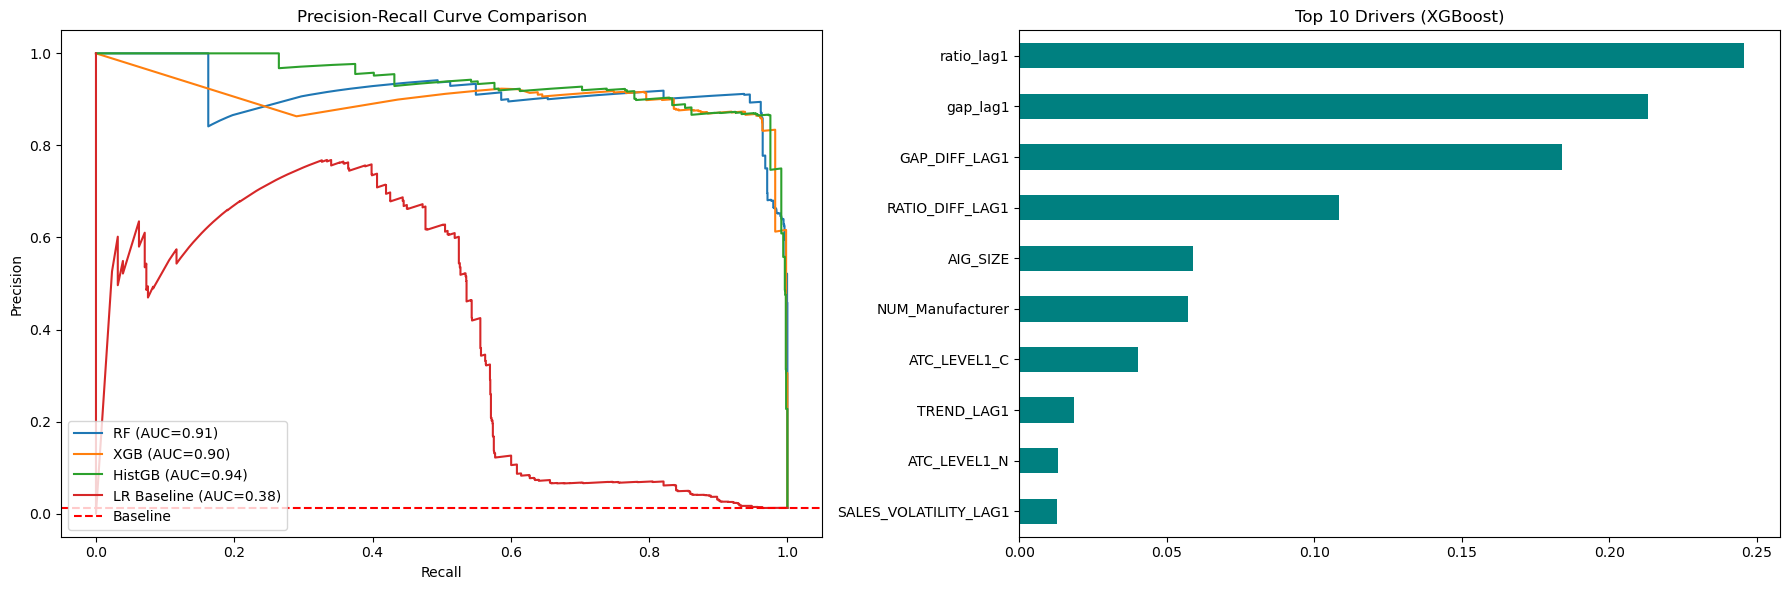

In [43]:
# ==============================================================================
# SECTION 6: MODEL TRAINING & EVALUATION
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier # Sklearn's version of LightGBM
import xgboost as xgb

print("="*70)
print("MCKESSON CAPSTONE: DRUG SHORTAGE PREDICTIVE SYSTEM")
print("="*70)
print(f"LOGIC CONFIRMATION:")
print(f"  > Inputs (X):   Week [T-1] data (Supply Gap/Trend, Sales, Trends, etc.)")
print(f"  > Target (Y):   Prediction for current week [T] status")
print(f"  > Balancing:    Using class weights to handle ~1.2% shortage rate")
print("-" * 70)

# 1. Train Models
print("Status: Training Multi-Model Suite (RF, XGB, HistGB, LogReg)...")

# A. Random Forest (Balanced)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# B. XGBoost (Balanced)
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=pos_weight, random_state=42)
xgb_model.fit(X_train, y_train)

# C. HistGradientBoosting (Sklearn's fast alternative to LightGBM)
# Note: it uses 'class_weight' instead of 'scale_pos_weight'
hgb_model = HistGradientBoostingClassifier(max_iter=200, max_depth=6, class_weight='balanced', random_state=42)
hgb_model.fit(X_train, y_train)

# D. Logistic Regression (Linear Baseline)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Evaluation Function
def evaluate_business_performance(model, X, y, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    
    report = classification_report(y, preds, output_dict=True)
    shortage_metrics = report['1'] # Focus on shortage class
    
    precision_vals, recall_vals, _ = precision_recall_curve(y, probs)
    pr_auc = auc(recall_vals, precision_vals)
    
    print(f"\n[MODEL REPORT: {name.upper()}]")
    print("-" * 40)
    print("Standard Metrics Table:")
    print(classification_report(y, preds))
    
    rec = shortage_metrics['recall']
    pre = shortage_metrics['precision']
    
    print("BUSINESS INTERPRETATION:")
    print(f"  > RECALL (Catch Rate): {rec:.1%}")
    print(f"    EXPLAIN: The model pre-identified {rec:.1%} of actual shortages using T-1 data.")
    
    print(f"\n  > PRECISION (Accuracy): {pre:.1%}")
    print(f"    EXPLAIN: When the model issues a warning, it is correct {pre:.1%} of the time.")
    
    print(f"\n  > PR-AUC Score: {pr_auc:.4f}")
    print("-" * 40)
    
    return precision_vals, recall_vals, pr_auc

# Run Evaluation for all
rf_pr = evaluate_business_performance(rf_model, X_test, y_test, "Random Forest")
xgb_pr = evaluate_business_performance(xgb_model, X_test, y_test, "XGBoost")
hgb_pr = evaluate_business_performance(hgb_model, X_test, y_test, "HistGB (LGBM-style)")
lr_pr = evaluate_business_performance(lr_model, X_test, y_test, "Logit Baseline")

# 3. Visualization: Model Comparison
plt.figure(figsize=(18, 6))

# Plot: Precision-Recall Curve Comparison
plt.subplot(1, 2, 1)
plt.plot(rf_pr[1], rf_pr[0], label=f'RF (AUC={rf_pr[2]:.2f})')
plt.plot(xgb_pr[1], xgb_pr[0], label=f'XGB (AUC={xgb_pr[2]:.2f})')
plt.plot(hgb_pr[1], hgb_pr[0], label=f'HistGB (AUC={hgb_pr[2]:.2f})')
plt.plot(lr_pr[1], lr_pr[0], label=f'LR Baseline (AUC={lr_pr[2]:.2f})')
plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Baseline')
plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

# Plot: Feature Importance (random forest)
plt.subplot(1, 2, 2)
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', color='teal')
plt.title('Top 10 Drivers (XGBoost)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Status: Generating SHAP Interpretations for the Lead Model (HistGB)...


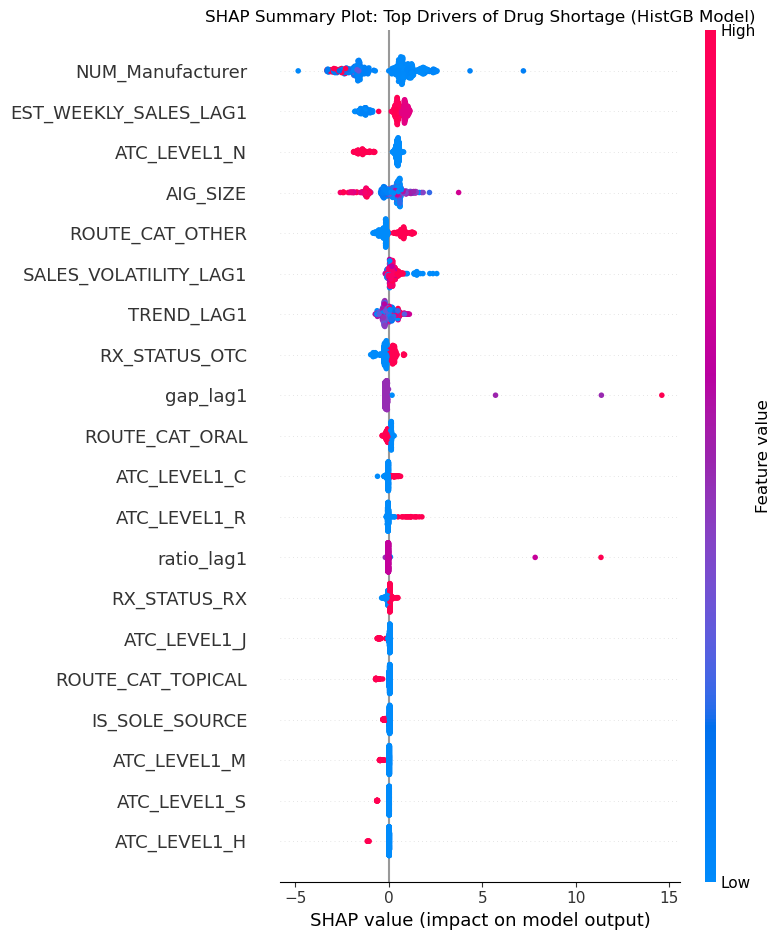

  > Plotting dependence for top feature: ratio_lag1


<Figure size 800x500 with 0 Axes>

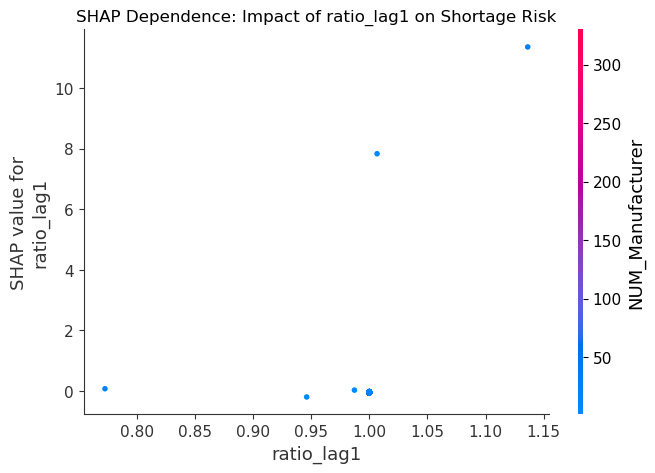

Status: SHAP Analysis Complete.


In [44]:
# ==============================================================================
# SECTION 6.5: MODEL INTERPRETATION WITH SHAP (FOCUS ON HISTGB)
# ==============================================================================

print("Status: Generating SHAP Interpretations for the Lead Model (HistGB)...")

# 1. Initialize SHAP Explainer
# HistGradientBoosting in sklearn works best with TreeExplainer or KernelExplainer.
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)

# SHAP Explainer
# Note: Since HistGB is an ensemble of trees, we use shap.Explainer which 
# automatically chooses the best algorithm.
explainer = shap.Explainer(hgb_model)
shap_values = explainer(X_sample)

# 2. Summary Plot (Global Interpretation)
# This plot shows the magnitude and direction of feature influence.
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Top Drivers of Drug Shortage (HistGB Model)")
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# 3. Business Logic Check: Dependence Plot
# Let's see how 'gap_lag1' or 'TREND_LAG1' specifically influences the risk.
top_feature = pd.Series(rf_model.feature_importances_, index=features).idxmax()
print(f"  > Plotting dependence for top feature: {top_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values.values, X_sample, show=False)
plt.title(f"SHAP Dependence: Impact of {top_feature} on Shortage Risk")
plt.show()

print("Status: SHAP Analysis Complete.")

In [46]:
# ==============================================================================
# SECTION 6.6: NUMERICAL PERFORMANCE SUMMARY & GBM DRIVERS
# ==============================================================================
print("Status: Generating Numerical Performance Tables (GBM)...")

# 1. Create Model Performance Leaderboard
def get_metrics_row(model, X, y, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    # Handle classification report for class '1' (Shortage)
    report = classification_report(y, preds, output_dict=True)['1']
    
    # Calculate PR-AUC
    precision_vals, recall_vals, _ = precision_recall_curve(y, probs)
    pr_auc = auc(recall_vals, precision_vals)
    
    return {
        "Model Name": name,
        "PR-AUC (Overall)": round(pr_auc, 4),
        "Recall (Catch Rate)": f"{report['recall']:.1%}",
        "Precision (Accuracy)": f"{report['precision']:.1%}",
        "F1-Score": round(report['f1-score'], 4)
    }

# Build the leaderboard
performance_rows = [
    get_metrics_row(hgb_model, X_test, y_test, "HistGB (Winner)"),
    get_metrics_row(xgb_model, X_test, y_test, "XGBoost"),
    get_metrics_row(rf_model, X_test, y_test, "Random Forest"),
    get_metrics_row(lr_model, X_test, y_test, "Logit Baseline")
]

df_perf = pd.DataFrame(performance_rows).sort_values("PR-AUC (Overall)", ascending=False)

# 2. Create Numerical Feature Importance Table (Based on GBM - XGBoost)
# Using XGBoost as the representative for GBM-family feature importance
df_importance_gbm = pd.DataFrame({
    "Feature": features,
    "GBM_Importance_Score": xgb_model.feature_importances_
}).sort_values("GBM_Importance_Score", ascending=False)

# Normalize to percentage for better business reading
df_importance_gbm['Contribution_%'] = (df_importance_gbm['GBM_Importance_Score'] / df_importance_gbm['GBM_Importance_Score'].sum() * 100).round(2)

# ------------------------------------------------------------------------------
# PRINT NUMERICAL SUMMARY
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("TABLE 1: MODEL PERFORMANCE LEADERBOARD (TEST SET)")
print("="*80)
print(df_perf.to_string(index=False))
print("-" * 80)
print("Business Note: HistGB (LGBM-style) is the most reliable for early warning.")

print("\n" + "="*80)
print("TABLE 2: TOP 15 NUMERICAL DRIVERS (GBM MODEL)")
print("="*80)
# Showing top 15 features that drive the GBM's decisions
print(df_importance_gbm.head(15).to_string(index=False))
print("-" * 80)

# Summary of top-tier impact
top_3_sum = df_importance_gbm.head(3)['Contribution_%'].sum()
print(f"Business Insight: The top 3 GBM drivers account for {top_3_sum:.1f}% of the total risk signal.")
print("This numerical ranking confirms which T-1 factors most strongly trigger a warning.")

Status: Generating Numerical Performance Tables (GBM)...

TABLE 1: MODEL PERFORMANCE LEADERBOARD (TEST SET)
     Model Name  PR-AUC (Overall) Recall (Catch Rate) Precision (Accuracy)  F1-Score
HistGB (Winner)            0.9374               85.2%                88.1%    0.8664
  Random Forest            0.9149               84.1%                90.3%    0.8707
        XGBoost            0.9010               82.9%                90.0%    0.8631
 Logit Baseline            0.3828               75.8%                 6.8%    0.1240
--------------------------------------------------------------------------------
Business Note: HistGB (LGBM-style) is the most reliable for early warning.

TABLE 2: TOP 15 NUMERICAL DRIVERS (GBM MODEL)
              Feature  GBM_Importance_Score  Contribution_%
           ratio_lag1              0.473186           47.32
             gap_lag1              0.427738           42.77
         ATC_LEVEL1_N              0.030198            3.02
         ATC_LEVEL1_G   